In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
customers = pd.read_excel("Task 02_dataset.xlsx", sheet_name="customers")


In [5]:
network_usage = pd.read_excel("Task 02_dataset.xlsx", sheet_name="network_usage")

In [6]:
network_issues = pd.read_excel("Task 02_dataset.xlsx", sheet_name="network_issues")

In [7]:
billing = pd.read_excel("Task 02_dataset.xlsx", sheet_name="billing")

In [8]:
customers.head()

,customer_id,customer_type,age,city,signup_date
0,1,Prepaid,34,Kolkata,2020-10-21
1,2,Postpaid,26,Chennai,2022-12-05
2,3,Postpaid,50,Mumbai,2023-02-10
3,4,Prepaid,37,Chennai,2020-01-17
4,5,Prepaid,30,Delhi,2020-12-25


In [9]:
issue_counts = network_issues.groupby('customer_id').size().reset_index(name='issue_count')

customer_risk = pd.merge(
    issue_counts,
    billing[['customer_id','payment_status']],
    on='customer_id',
    how='left'
)

In [10]:
network_usage['Heavy_Usage'] = network_usage['data_used_gb'].apply(
    lambda x: 'Heavy User' if x > 5 else 'Normal User'
)

network_usage.head()

,usage_id,customer_id,usage_date,data_used_gb,call_minutes,network_type,Month,Year,High_Usage,Heavy_Usage
0,10001,288,2023-09-20,2.01,49,4G,9,2023,Normal,Normal User
1,10002,167,2023-10-25,2.50,134,5G,10,2023,Normal,Normal User
2,10003,109,2024-04-29,0.74,117,4G,4,2024,Normal,Normal User
3,10004,494,2022-02-19,7.42,59,4G,2,2022,High,Heavy User
4,10005,36,2023-05-17,0.47,124,5G,5,2023,Normal,Normal User


In [11]:
customers.info()
network_usage.info()
network_issues.info()
billing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    500 non-null    int64         
 1   customer_type  500 non-null    object        
 2   age            500 non-null    int64         
 3   city           500 non-null    object        
 4   signup_date    500 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 19.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   usage_id      6000 non-null   int64         
 1   customer_id   6000 non-null   int64         
 2   usage_date    6000 non-null   datetime64[ns]
 3   data_used_gb  6000 non-null   float64       
 4   call_minutes  6000 non-null   int64         
 5   network

In [12]:
customers.isnull().sum()
network_usage.isnull().sum()
network_issues.isnull().sum()
billing.isnull().sum()

,0
bill_id,0
customer_id,0
bill_month,0
bill_amount,0
payment_status,0


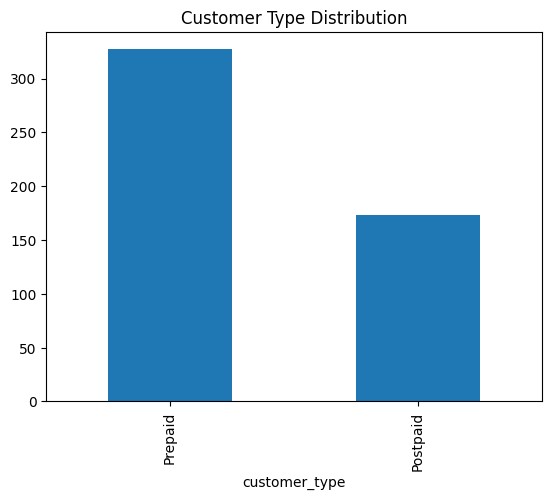

In [13]:
customers['customer_type'].value_counts().plot(kind='bar')

plt.title('Customer Type Distribution')
plt.show()

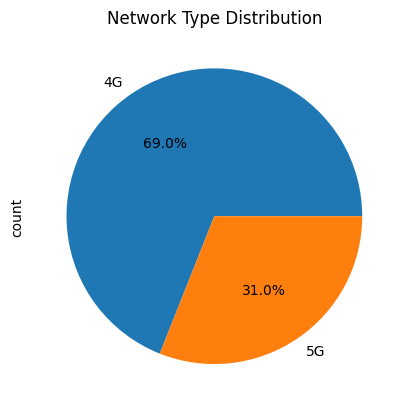

In [14]:
network_usage['network_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Network Type Distribution')
plt.show()

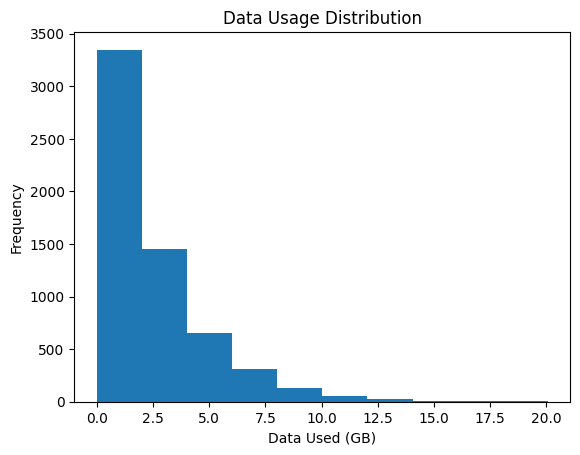

In [15]:
plt.hist(network_usage['data_used_gb'])

plt.title('Data Usage Distribution')
plt.xlabel('Data Used (GB)')
plt.ylabel('Frequency')

plt.show()

In [16]:
issue_counts = network_issues.groupby('customer_id').size().reset_index(name='issue_count')

issue_counts.head()

,customer_id,issue_count
0,1,6
1,2,7
2,3,3
3,4,6
4,5,8


In [17]:
customer_risk = pd.merge(
    issue_counts,
    billing[['customer_id', 'payment_status']],
    on='customer_id',
    how='left'
)

customer_risk.head()

,customer_id,issue_count,payment_status
0,1,6,Paid
1,1,6,Paid
2,1,6,Failed
3,1,6,Paid
4,1,6,Delayed


In [18]:
def risk_score(issue_count, payment_status):

    if issue_count >= 5 and payment_status == 'Delayed':
        return 'High Risk'

    elif issue_count >= 3:
        return 'Medium Risk'

    else:
        return 'Low Risk'

In [19]:
customer_risk['Risk_Score'] = customer_risk.apply(
    lambda row: risk_score(
        row['issue_count'],
        row['payment_status']
    ),
    axis=1
)

customer_risk.head(10)

,customer_id,issue_count,payment_status,Risk_Score
0,1,6,Paid,Medium Risk
1,1,6,Paid,Medium Risk
2,1,6,Failed,Medium Risk
3,1,6,Paid,Medium Risk
4,1,6,Delayed,High Risk
5,1,6,Paid,Medium Risk
6,1,6,Paid,Medium Risk
7,1,6,Paid,Medium Risk
8,1,6,Paid,Medium Risk
9,1,6,Paid,Medium Risk


In [20]:
customer_risk['Risk_Score'].value_counts()

,count
Risk_Score,
Medium Risk,4146
High Risk,523
Low Risk,320


q2

In [21]:
network_usage['Heavy_Usage'] = network_usage['data_used_gb'].apply(
    lambda x: 'Heavy User' if x > 5 else 'Normal User'
)

network_usage[['customer_id','data_used_gb','Heavy_Usage']].head(10)

,customer_id,data_used_gb,Heavy_Usage
0,288,2.01,Normal User
1,167,2.50,Normal User
2,109,0.74,Normal User
3,494,7.42,Heavy User
4,36,0.47,Normal User
5,232,8.43,Heavy User
6,229,0.04,Normal User
7,353,1.64,Normal User
8,164,1.01,Normal User
9,387,1.49,Normal User


In [22]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    500 non-null    int64         
 1   customer_type  500 non-null    object        
 2   age            500 non-null    int64         
 3   city           500 non-null    object        
 4   signup_date    500 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 19.7+ KB


In [23]:
network_usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   usage_id      6000 non-null   int64         
 1   customer_id   6000 non-null   int64         
 2   usage_date    6000 non-null   datetime64[ns]
 3   data_used_gb  6000 non-null   float64       
 4   call_minutes  6000 non-null   int64         
 5   network_type  6000 non-null   object        
 6   Month         6000 non-null   int64         
 7   Year          6000 non-null   int64         
 8   High_Usage    6000 non-null   object        
 9   Heavy_Usage   6000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 468.9+ KB


In [24]:
network_issues.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   issue_id             3000 non-null   int64         
 1   customer_id          3000 non-null   int64         
 2   issue_date           3000 non-null   datetime64[ns]
 3   issue_type           3000 non-null   object        
 4   resolution_time_hrs  3000 non-null   int64         
 5   resolved             3000 non-null   object        
 6   City                 3000 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 164.2+ KB


In [25]:
billing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   bill_id         5000 non-null   int64         
 1   customer_id     5000 non-null   int64         
 2   bill_month      5000 non-null   datetime64[ns]
 3   bill_amount     5000 non-null   int64         
 4   payment_status  5000 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 195.4+ KB


In [26]:
print(customers.isnull().sum())
print(network_usage.isnull().sum())
print(network_issues.isnull().sum())
print(billing.isnull().sum())

customer_id      0
customer_type    0
age              0
city             0
signup_date      0
dtype: int64
usage_id        0
customer_id     0
usage_date      0
data_used_gb    0
call_minutes    0
network_type    0
Month           0
Year            0
High_Usage      0
Heavy_Usage     0
dtype: int64
issue_id               0
customer_id            0
issue_date             0
issue_type             0
resolution_time_hrs    0
resolved               0
City                   0
dtype: int64
bill_id           0
customer_id       0
bill_month        0
bill_amount       0
payment_status    0
dtype: int64


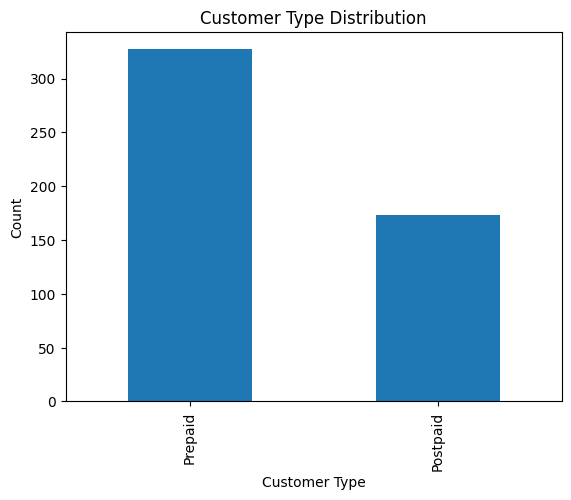

In [27]:
customers['customer_type'].value_counts().plot(kind='bar')

plt.title('Customer Type Distribution')
plt.xlabel('Customer Type')
plt.ylabel('Count')

plt.show()

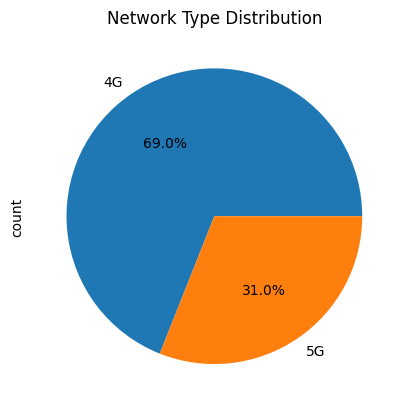

In [28]:
network_usage['network_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Network Type Distribution')

plt.show()

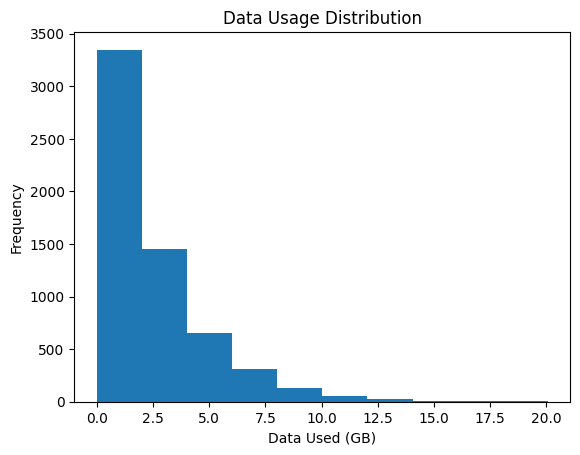

In [29]:
plt.hist(network_usage['data_used_gb'])

plt.title('Data Usage Distribution')
plt.xlabel('Data Used (GB)')
plt.ylabel('Frequency')

plt.show()